# Adapter :: LoRA
- Ref: 
    - https://huggingface.co/docs/diffusers/v0.34.0/en/tutorials/using_peft_for_inference
    - https://huggingface.co/docs/diffusers/v0.34.0/en/training/lora
    


## 0. Configure device

In [1]:
#@title
import torch

if torch.backends.mps.is_available():
    t_device = torch.device("mps")
    s_device = "mps"
    print(f"Current memory allocated on MPS: {torch.mps.current_allocated_memory()} bytes")
    print(f"Driver memory allocated on MPS: {torch.mps.driver_allocated_memory()} bytes")
    if torch.mps.driver_allocated_memory() - torch.mps.current_allocated_memory()< 1e4:
        print("Not enough mps memory, convert to cpu mode")
        t_device = torch.device("cpu")
        s_device = "cpu"
elif torch.cuda.is_available():
    t_device = torch.device("cuda")
    s_device = "cuda"
else:
    t_device = torch.device("cpu")
    s_device = "cpu"
print(t_device)

Current memory allocated on MPS: 0 bytes
Driver memory allocated on MPS: 393216 bytes
mps


### 0. LoRA

#### 0.1 text-to-Image

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

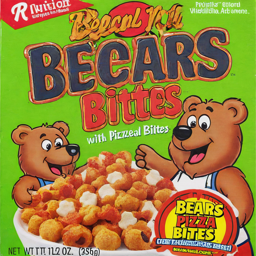

In [6]:
import torch
from diffusers import AutoPipelineForText2Image

pipeline = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to(t_device)
pipeline.load_lora_weights(
    "ostris/super-cereal-sdxl-lora",
    weight_name="cereal_box_sdxl_v1.safetensors",
    adapter_name="cereal"
)
pipeline("bears, pizza bites").images[0].resize((256, 256))

In [ ]:
prompt = "CAKEIFY a person using a folk to cut a cake shaped like a Pikachu plushie"
image = load_image("https://huggingface.co/Lightricks/LTX-Video-Cakeify-LoRA/resolve/main/assets/images/pikachu.png")
output = pipeline(
    prompt=prompt,
    image=image,
    width=576,
    height=576,
    num_frames=161,
    decode_timestep=0.03,
    decode_noise_scale=0.025,
    num_inference_steps=50,
)

  0%|          | 0/50 [00:00<?, ?it/s]

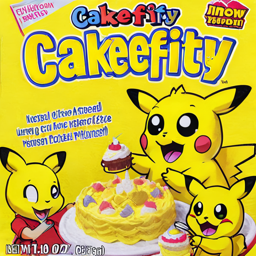

In [ ]:
output.images[0].resize((256, 256))

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

pytorch_lora_weights.safetensors:   0%|          | 0.00/23.4M [00:00<?, ?B/s]

  0%|          | 0/50 [00:00<?, ?it/s]

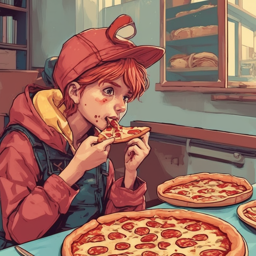

In [10]:
import torch
from diffusers import AutoPipelineForText2Image

pipeline = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to(t_device)

pipeline.unet.load_lora_adapter(
    "jbilcke-hf/sdxl-cinematic-1",
    weight_name="pytorch_lora_weights.safetensors",
    adapter_name="cinematic",
    prefix="unet"
)

# use cnmt in the prompt to trigger the LoRA
pipeline("A cute cnmt eating a slice of pizza, stunning color scheme, masterpiece, illustration").images[0].resize((256, 256))

## 1.torch.compile

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

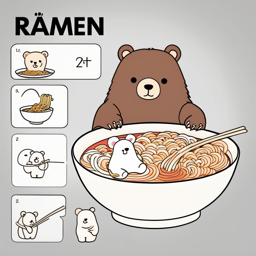

In [11]:
import torch
from diffusers import DiffusionPipeline

# load base model and LoRA
pipeline = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to(t_device)
pipeline.load_lora_weights(
    "ostris/ikea-instructions-lora-sdxl",
    weight_name="ikea_instructions_xl_v1_5.safetensors",
    adapter_name="ikea"
)

# activate LoRA and set adapter weight
pipeline.set_adapters("ikea", adapter_weights=0.7)

# fuse LoRAs and unload weights
pipeline.fuse_lora(adapter_names=["ikea"], lora_scale=1.0)
pipeline.unload_lora_weights()

pipeline.unet.to(memory_format=torch.channels_last)

# - MPS could not support torch.compile
# pipeline.unet = torch.compile(pipeline.unet, mode="reduce-overhead", fullgraph=True)

pipeline("A bowl of ramen shaped like a cute kawaii bear").images[0].resize((256, 256))

### -- Does not work on MacOS :: "torch.compile"

### 2.Weight Scale


#### 2.1 Simple use case

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

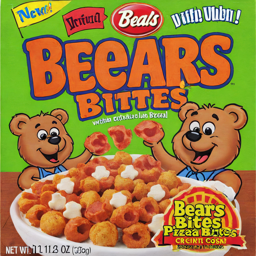

In [12]:
import torch
from diffusers import AutoPipelineForText2Image

pipeline = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to(t_device)
pipeline.load_lora_weights(
    "ostris/super-cereal-sdxl-lora",
    weight_name="cereal_box_sdxl_v1.safetensors",
    adapter_name="cereal"
)
pipeline("bears, pizza bites", cross_attention_kwargs={"scale": 1.0}).images[0].resize((256, 256))

#### 2.2. Fine Controls


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
Lora weight dict for adapter 'cereal' contains text_encoder,but this will be ignored because cereal does not contain weights for text_encoder.Valid parts for cereal are: ['unet', 'text_encoder_2'].


  0%|          | 0/50 [00:00<?, ?it/s]

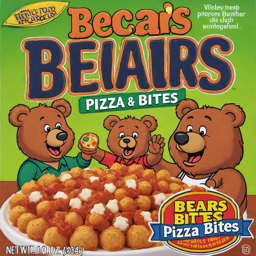

In [13]:
import torch
from diffusers import AutoPipelineForText2Image

pipeline = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to(t_device)
pipeline.load_lora_weights(
    "ostris/super-cereal-sdxl-lora",
    weight_name="cereal_box_sdxl_v1.safetensors",
    adapter_name="cereal"
)
scales = {
    "text_encoder": 0.5,
    "text_encoder_2": 0.5,
    "unet": {
        "down": 0.9,
        "up": {
            "block_0": 0.6,
            "block_1": [0.4, 0.8, 1.0],
        }
    }
}
pipeline.set_adapters("cereal", scales)
pipeline("bears, pizza bites").images[0].resize((256, 256))

### 3. Hotswapping

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
/Users/hyunjae.k/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doin

  0%|          | 0/50 [00:00<?, ?it/s]

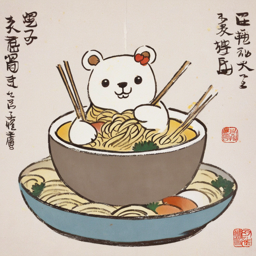

In [ ]:
import torch
from diffusers import DiffusionPipeline

# load base model and LoRAs
pipeline = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to(t_device)

# 1. enable_lora_hotswap
max_rank = 128
pipeline.enable_lora_hotswap(target_rank=max_rank)
pipeline.load_lora_weights(
    "ostris/ikea-instructions-lora-sdxl",
    weight_name="ikea_instructions_xl_v1_5.safetensors",
    adapter_name="ikea"
)

# 2. hotswap
pipeline.load_lora_weights(
    "lordjia/by-feng-zikai",
    # hotswap=True,
    adapter_name="ikea_0"
)

pipeline("A bowl of ramen shaped like a cute kawaii bear").images[0].resize((256, 256))



### 4. Merge

#### 4.1 set_adapter

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue

  0%|          | 0/50 [00:00<?, ?it/s]

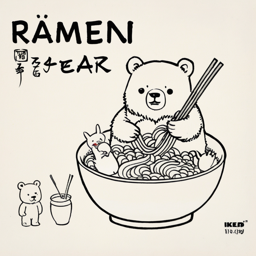

In [18]:
import torch
from diffusers import DiffusionPipeline

pipeline = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to(t_device)
pipeline.load_lora_weights(
    "ostris/ikea-instructions-lora-sdxl",
    weight_name="ikea_instructions_xl_v1_5.safetensors",
    adapter_name="ikea"
)
pipeline.load_lora_weights(
    "lordjia/by-feng-zikai",
    weight_name="fengzikai_v1.0_XL.safetensors",
    adapter_name="feng"
)
pipeline.set_adapters(["ikea", "feng"], adapter_weights=[0.7, 0.8])
# use by Feng Zikai to activate the lordjia/by-feng-zikai LoRA
pipeline("A bowl of ramen shaped like a cute kawaii bear, by Feng Zikai", cross_attention_kwargs={"scale": 1.0}).images[0].resize((256, 256))

  0%|          | 0/50 [00:00<?, ?it/s]

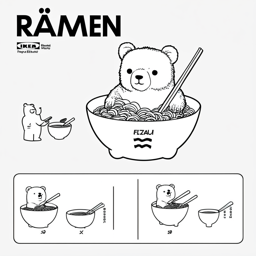

In [19]:
pipeline.set_adapters(["ikea", "feng"], adapter_weights=[1.0, 0.0])
# use by Feng Zikai to activate the lordjia/by-feng-zikai LoRA
pipeline("A bowl of ramen shaped like a cute kawaii bear, by Feng Zikai", cross_attention_kwargs={"scale": 1.0}).images[0].resize((256, 256))

  0%|          | 0/50 [00:00<?, ?it/s]

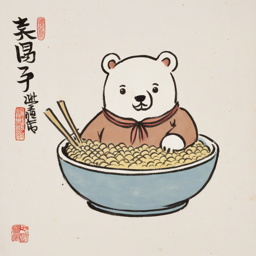

In [20]:
pipeline.set_adapters(["ikea", "feng"], adapter_weights=[0.0, 1.0])
# use by Feng Zikai to activate the lordjia/by-feng-zikai LoRA
pipeline("A bowl of ramen shaped like a cute kawaii bear, by Feng Zikai", cross_attention_kwargs={"scale": 1.0}).images[0].resize((256, 256))

  0%|          | 0/50 [00:00<?, ?it/s]

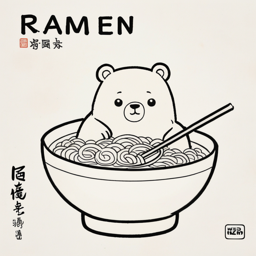

In [21]:
pipeline.set_adapters(["ikea", "feng"], adapter_weights=[0.5, 0.5])
# use by Feng Zikai to activate the lordjia/by-feng-zikai LoRA
pipeline("A bowl of ramen shaped like a cute kawaii bear, by Feng Zikai", cross_attention_kwargs={"scale": 1.0}).images[0].resize((256, 256))

#### 4.3 fuse lora

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
/Users/hyunjae.k/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doin

  0%|          | 0/50 [00:00<?, ?it/s]

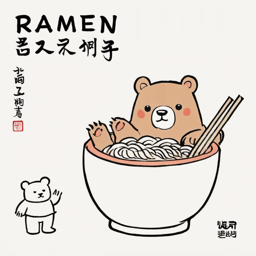

In [4]:
import torch
from diffusers import DiffusionPipeline

pipeline = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to(t_device)
pipeline.load_lora_weights(
    "ostris/ikea-instructions-lora-sdxl",
    weight_name="ikea_instructions_xl_v1_5.safetensors",
    adapter_name="ikea"
)
pipeline.load_lora_weights(
    "lordjia/by-feng-zikai",
    weight_name="fengzikai_v1.0_XL.safetensors",
    adapter_name="feng"
)
pipeline.set_adapters(["ikea", "feng"], adapter_weights=[0.7, 0.8])

pipeline.fuse_lora(adapter_names=["ikea", "feng"], lora_scale=1.0)

pipeline("A bowl of ramen shaped like a cute kawaii bear, by Feng Zikai").images[0].resize((256, 256))

In [5]:
pipeline.unload_lora_weights()
pipeline.save_pretrained("./temp/lora_fuse_model")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

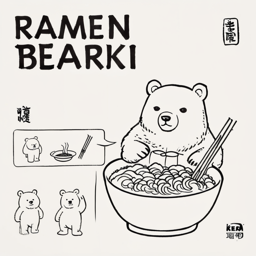

In [6]:
pipeline = DiffusionPipeline.from_pretrained(
    "./temp/lora_fuse_model",
    torch_dtype=torch.float16,
).to(t_device)
pipeline("A bowl of ramen shaped like a cute kawaii bear, by Feng Zikai").images[0].resize((256, 256))